# Model Evaluation: Spatial CRE Maps (rngseed0)

This notebook compares **CRE truth vs model prediction** for:
- `CanESM5_rlut_rngseed0`
- `CanESM5_rsut_rngseed0`

For each experiment, it randomly samples test years and plots global maps of:
1. Truth
2. Prediction
3. Prediction error (`pred - truth`)

In [1]:
import os
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import xarray as xr

BASE_DIR = Path("../../").resolve()
MODEL_DIRECTORY = BASE_DIR / "data" / "saved_models"
PREDICTIONS_DIRECTORY = BASE_DIR / "data" / "saved_predictions"
SPLIT_DIRECTORY = BASE_DIR / "data" / "splits"
FIGURES_DIRECTORY = BASE_DIR / "data" / "figures"

FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)

print(f"Using base directory: {BASE_DIR}")
print(f"Models: {MODEL_DIRECTORY}")
print(f"Predictions: {PREDICTIONS_DIRECTORY}")
print(f"Splits: {SPLIT_DIRECTORY}")

Using base directory: C:\Users\altti\Documents\ESS 469\Paleo_Climate_ML
Models: C:\Users\altti\Documents\ESS 469\Paleo_Climate_ML\data\saved_models
Predictions: C:\Users\altti\Documents\ESS 469\Paleo_Climate_ML\data\saved_predictions
Splits: C:\Users\altti\Documents\ESS 469\Paleo_Climate_ML\data\splits


In [ ]:
def get_model_name(experiment_name: str, rng_seed: int = 0) -> str:
    return f"{experiment_name}_rngseed{rng_seed}"


def _open_dataarray(path: Path) -> xr.DataArray:
    try:
        return xr.open_dataarray(path)
    except Exception:
        ds = xr.open_dataset(path)
        first_var = list(ds.data_vars)[0]
        return ds[first_var]


def _load_test_inputs() -> tuple[np.ndarray, xr.DataArray]:
    x_test_da = _open_dataarray(SPLIT_DIRECTORY / "X_test.nc")
    x = np.asarray(x_test_da.values)
    if x.ndim != 4:
        raise ValueError(f"Expected X_test as (member, time, lat, lon), got {x.shape}")

    n_members, n_time, n_lat, n_lon = x.shape
    x_flat = x.reshape((n_members * n_time, n_lat, n_lon, 1))
    return x_flat, x_test_da


def _load_test_labels(experiment_name: str) -> tuple[np.ndarray, xr.DataArray]:
    suffix = "rsut" if experiment_name.endswith("rsut") else "rlut"
    y_test_da = _open_dataarray(SPLIT_DIRECTORY / f"y_test_{suffix}.nc")
    y = np.asarray(y_test_da.values)

    if y.ndim < 4:
        raise ValueError(
            f"Expected y_test_{suffix}.nc to include spatial dims (member, time, lat, lon), got {y.shape}"
        )

    y_flat = y.reshape((y.shape[0] * y.shape[1], -1))
    return y_flat, y_test_da


def _load_predictions_or_infer(experiment_name: str, rng_seed: int = 0) -> tuple[np.ndarray, np.ndarray, xr.DataArray]:
    model_name = get_model_name(experiment_name, rng_seed)
    pred_path = PREDICTIONS_DIRECTORY / f"{model_name}_predictions.pickle"

    y_true_flat, y_test_da = _load_test_labels(experiment_name)

    if pred_path.exists():
        with open(pred_path, "rb") as f:
            payload = pickle.load(f)
        y_pred_flat = np.asarray(payload["pred_test"])
        print(f"Loaded saved predictions: {pred_path.name}")
    else:
        model_path = MODEL_DIRECTORY / f"{model_name}_model.keras"
        if not model_path.exists():
            raise FileNotFoundError(
                f"Could not find predictions or model for {model_name}. Checked: {pred_path} and {model_path}"
            )

        x_test_flat, _ = _load_test_inputs()
        model = tf.keras.models.load_model(model_path, compile=False)
        y_pred_flat = model.predict(x_test_flat, verbose=0)
        print(f"Generated predictions from model: {model_path.name}")

    if y_pred_flat.shape != y_true_flat.shape:
        raise ValueError(f"Prediction shape {y_pred_flat.shape} does not match truth shape {y_true_flat.shape}")

    return y_true_flat, y_pred_flat, y_test_da


def _index_to_member_time(flat_index: int, n_time: int) -> tuple[int, int]:
    member_idx = flat_index // n_time
    time_idx = flat_index % n_time
    return member_idx, time_idx


def _time_label(y_test_da: xr.DataArray, time_idx: int) -> str:
    if "time" not in y_test_da.coords:
        return f"t={time_idx}"

    t_val = y_test_da["time"].values[time_idx]
    if np.issubdtype(np.asarray(t_val).dtype, np.datetime64):
        return np.datetime_as_string(t_val, unit="Y")
    return str(t_val)


def _compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    residual = y_pred - y_true
    mae = float(np.mean(np.abs(residual)))
    mse = float(np.mean(residual**2))
    rmse = float(np.sqrt(mse))
    bias = float(np.mean(residual))

    y_true_mean = np.mean(y_true)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true_mean) ** 2)
    r2 = float(1.0 - (ss_res / ss_tot)) if ss_tot != 0 else np.nan

    data_range = np.max(y_true) - np.min(y_true)
    nrmse = float(rmse / data_range) if data_range != 0 else np.nan
    skill_percent = float(max(0.0, (1.0 - nrmse) * 100.0)) if np.isfinite(nrmse) else np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Bias": bias,
        "SkillPercent": skill_percent,
    }


def plot_random_spatial_comparison(experiment_name: str, rng_seed: int = 0, n_samples: int = 4, sample_seed: int = 7):
    y_true_flat, y_pred_flat, y_test_da = _load_predictions_or_infer(experiment_name, rng_seed=rng_seed)

    n_members, n_time, n_lat, n_lon = y_test_da.shape[:4]
    total_samples = n_members * n_time

    if n_samples > total_samples:
        n_samples = total_samples

    rng = np.random.default_rng(sample_seed)
    sample_idx = np.sort(rng.choice(total_samples, size=n_samples, replace=False))

    lat = y_test_da["lat"].values if "lat" in y_test_da.coords else np.arange(n_lat)
    lon = y_test_da["lon"].values if "lon" in y_test_da.coords else np.arange(n_lon)

    fig, axes = plt.subplots(n_samples, 3, figsize=(15, 3.6 * n_samples), constrained_layout=True)
    if n_samples == 1:
        axes = np.array([axes])

    fig.suptitle(f"{experiment_name} rngseed{rng_seed}: Random Test-Year Spatial CRE Comparison", fontsize=14)

    for row, idx in enumerate(sample_idx):
        member_idx, time_idx = _index_to_member_time(idx, n_time)
        label = _time_label(y_test_da, time_idx)

        truth_map = y_true_flat[idx].reshape(n_lat, n_lon)
        pred_map = y_pred_flat[idx].reshape(n_lat, n_lon)
        err_map = pred_map - truth_map

        panel_min = np.nanpercentile(np.concatenate([truth_map.ravel(), pred_map.ravel()]), 1)
        panel_max = np.nanpercentile(np.concatenate([truth_map.ravel(), pred_map.ravel()]), 99)
        err_lim = np.nanpercentile(np.abs(err_map), 99)
        if not np.isfinite(err_lim) or err_lim == 0:
            err_lim = 1.0

        im0 = axes[row, 0].pcolormesh(lon, lat, truth_map, shading="auto", cmap="coolwarm", vmin=panel_min, vmax=panel_max)
        im1 = axes[row, 1].pcolormesh(lon, lat, pred_map, shading="auto", cmap="coolwarm", vmin=panel_min, vmax=panel_max)
        im2 = axes[row, 2].pcolormesh(lon, lat, err_map, shading="auto", cmap="RdBu_r", vmin=-err_lim, vmax=err_lim)

        axes[row, 0].set_title(f"Truth | member={member_idx}, time={label}")
        axes[row, 1].set_title("Prediction")
        axes[row, 2].set_title("Error (pred - truth)")

        for col in range(3):
            axes[row, col].set_xlabel("Longitude")
            axes[row, col].set_ylabel("Latitude")

        fig.colorbar(im0, ax=axes[row, 0], shrink=0.85)
        fig.colorbar(im1, ax=axes[row, 1], shrink=0.85)
        fig.colorbar(im2, ax=axes[row, 2], shrink=0.85)

    out_name = FIGURES_DIRECTORY / f"{experiment_name}_rngseed{rng_seed}_random_spatial_comparison.png"
    fig.savefig(out_name, dpi=250, bbox_inches="tight")
    print(f"Saved figure: {out_name}")

    sample_true = y_true_flat[sample_idx]
    sample_pred = y_pred_flat[sample_idx]
    metrics = _compute_metrics(sample_true, sample_pred)

    print(f"\n{experiment_name} rngseed{rng_seed} metrics on sampled years:")
    print(f"  MAE:          {metrics['MAE']:.4f}")
    print(f"  RMSE:         {metrics['RMSE']:.4f}")
    print(f"  R2:           {metrics['R2']:.4f}")
    print(f"  Mean Bias:    {metrics['Bias']:.4f}")
    print(f"  Skill (%):    {metrics['SkillPercent']:.2f}")

    plt.show()
    return metrics

Generated predictions from model: CanESM5_rlut_rngseed0_model.keras
Saved figure: C:\Users\altti\Documents\ESS 469\Paleo_Climate_ML\data\figures\CanESM5_rlut_rngseed0_random_spatial_comparison.png


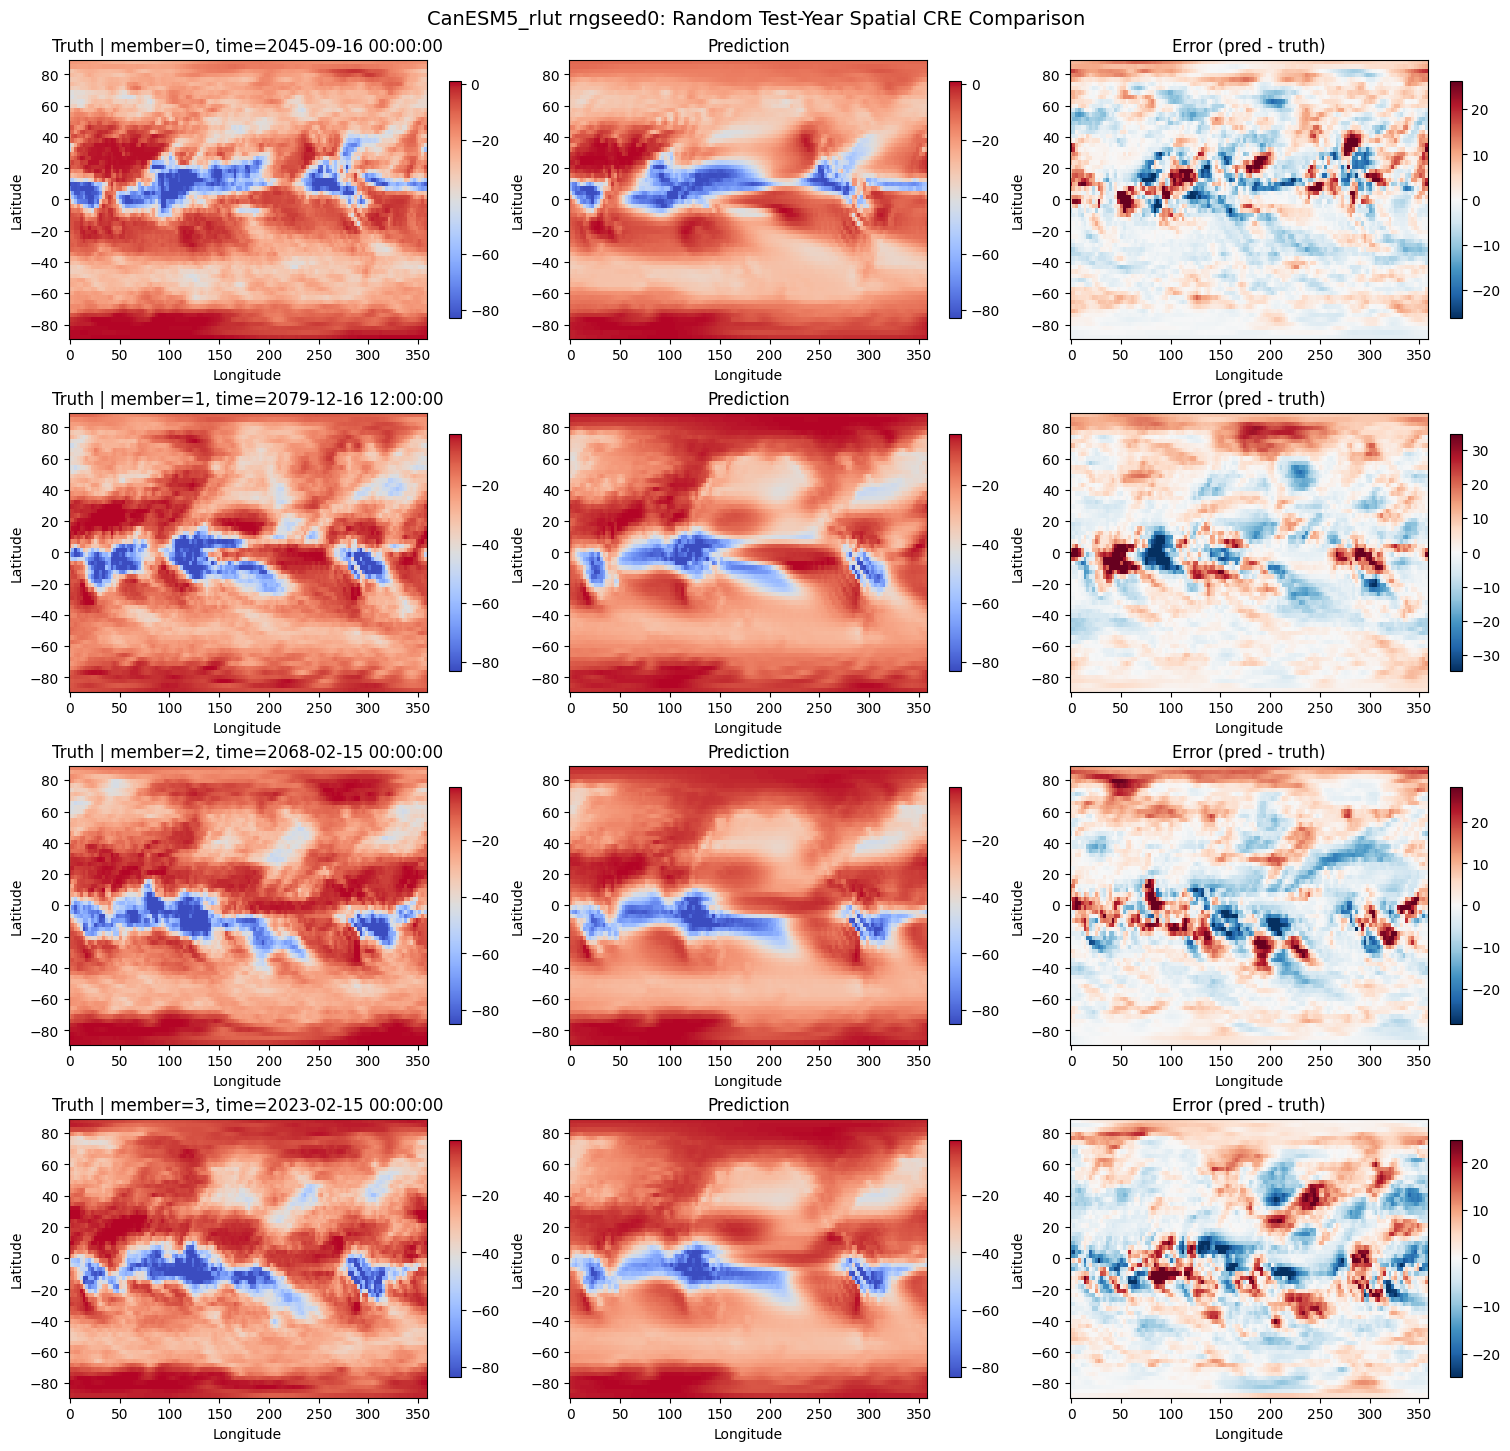

Generated predictions from model: CanESM5_rsut_rngseed0_model.keras
Saved figure: C:\Users\altti\Documents\ESS 469\Paleo_Climate_ML\data\figures\CanESM5_rsut_rngseed0_random_spatial_comparison.png


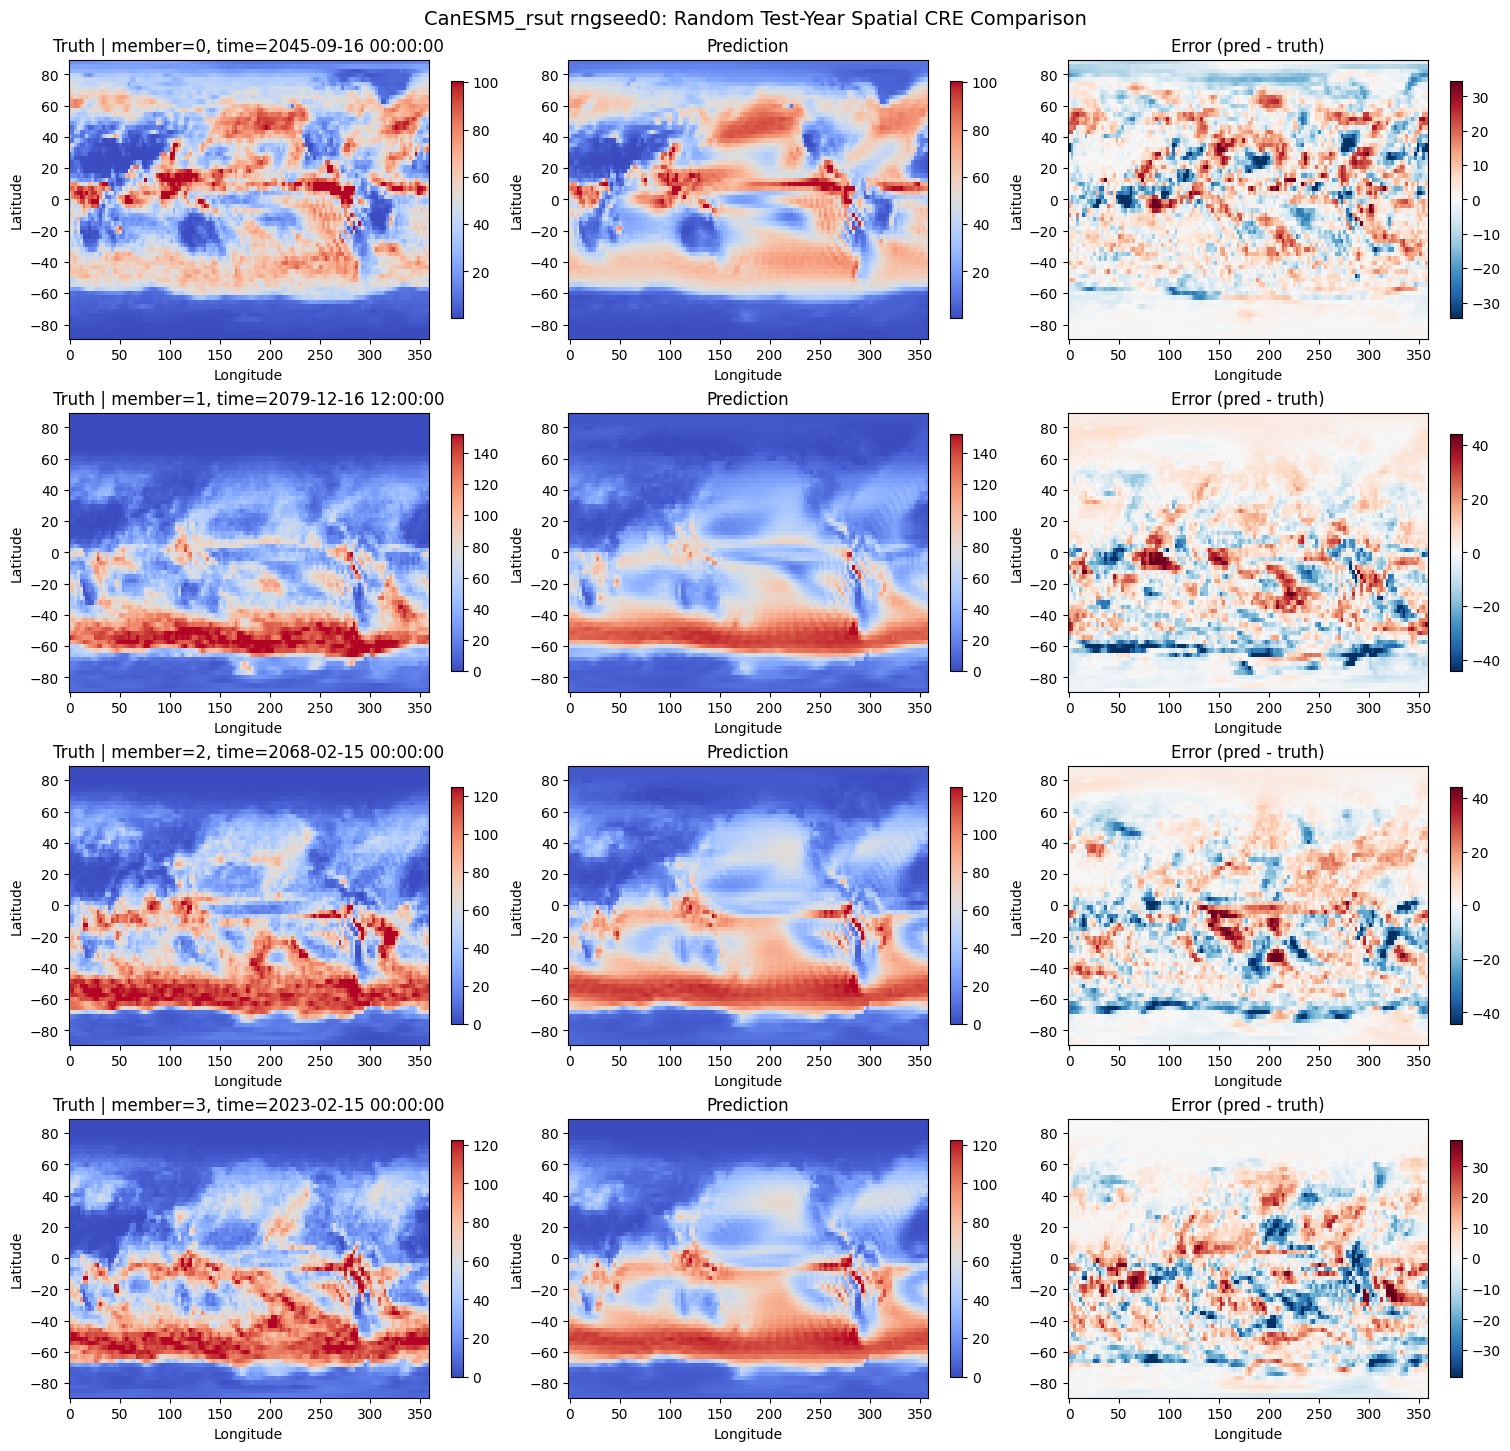

In [ ]:
RNG_SEED = 0
N_RANDOM_YEARS = 4
RANDOM_SELECTION_SEED = 42

metrics_rlut = plot_random_spatial_comparison(
    experiment_name="CanESM5_rlut",
    rng_seed=RNG_SEED,
    n_samples=N_RANDOM_YEARS,
    sample_seed=RANDOM_SELECTION_SEED,
)

metrics_rsut = plot_random_spatial_comparison(
    experiment_name="CanESM5_rsut",
    rng_seed=RNG_SEED,
    n_samples=N_RANDOM_YEARS,
    sample_seed=RANDOM_SELECTION_SEED,
)

print("\nSummary metrics (sampled random years):")
print("Model                 MAE      RMSE      R2       Bias     Skill(%)")
print(f"CanESM5_rlut_seed0    {metrics_rlut['MAE']:.4f}   {metrics_rlut['RMSE']:.4f}   {metrics_rlut['R2']:.4f}   {metrics_rlut['Bias']:.4f}   {metrics_rlut['SkillPercent']:.2f}")
print(f"CanESM5_rsut_seed0    {metrics_rsut['MAE']:.4f}   {metrics_rsut['RMSE']:.4f}   {metrics_rsut['R2']:.4f}   {metrics_rsut['Bias']:.4f}   {metrics_rsut['SkillPercent']:.2f}")

In [6]:
def evaluate_full_testset(experiment_name: str, rng_seed: int = 0) -> dict:
    y_true_flat, y_pred_flat, _ = _load_predictions_or_infer(experiment_name, rng_seed=rng_seed)
    metrics = _compute_metrics(y_true_flat, y_pred_flat)
    metrics["experiment"] = experiment_name
    metrics["rng_seed"] = rng_seed
    return metrics


full_rlut = evaluate_full_testset("CanESM5_rlut", rng_seed=RNG_SEED)
full_rsut = evaluate_full_testset("CanESM5_rsut", rng_seed=RNG_SEED)

print("Full test-set metrics:")
print("Model                 MAE      RMSE      R2       Bias     Skill(%)")
print(f"CanESM5_rlut_seed0    {full_rlut['MAE']:.4f}   {full_rlut['RMSE']:.4f}   {full_rlut['R2']:.4f}   {full_rlut['Bias']:.4f}   {full_rlut['SkillPercent']:.2f}")
print(f"CanESM5_rsut_seed0    {full_rsut['MAE']:.4f}   {full_rsut['RMSE']:.4f}   {full_rsut['R2']:.4f}   {full_rsut['Bias']:.4f}   {full_rsut['SkillPercent']:.2f}")

Generated predictions from model: CanESM5_rlut_rngseed0_model.keras
Generated predictions from model: CanESM5_rsut_rngseed0_model.keras
Full test-set metrics:
Model                 MAE      RMSE      R2       Bias     Skill(%)
CanESM5_rlut_seed0    5.3019   7.5866   0.8053   0.7359   94.41
CanESM5_rsut_seed0    8.4568   13.6108   0.8528   -0.5830   94.11


Generated predictions from model: CanESM5_rsut_rngseed0_model.keras
Generated predictions from model: CanESM5_rsut_rngseed1_model.keras
Generated predictions from model: CanESM5_rsut_rngseed2_model.keras
Generated predictions from model: CanESM5_rsut_rngseed3_model.keras
Generated predictions from model: CanESM5_rsut_rngseed4_model.keras
CanESM5_rsut full test-set metrics by random seed:
Seed   MAE      RMSE      R2       Bias     Skill(%)
0      8.4568   13.6108   0.8528   -0.5830   94.11
1      8.5266   13.8486   0.8476   -0.7929   94.01
2      9.1235   14.5734   0.8313   -0.4147   93.70
3      8.7523   14.0602   0.8429   -0.5383   93.92
4      8.3557   13.4622   0.8560   -0.7285   94.18

Variability summary across seeds (rsut):
MAE   mean=8.6430, std=0.2734, min=8.3557, max=9.1235
RMSE  mean=13.9110, std=0.3890, min=13.4622, max=14.5734
R2    mean=0.8461, std=0.0087, min=0.8313, max=0.8560
Bias  mean=-0.6115, std=0.1353, min=-0.7929, max=-0.4147
Skill mean=93.98, std=0.17, min=93.70

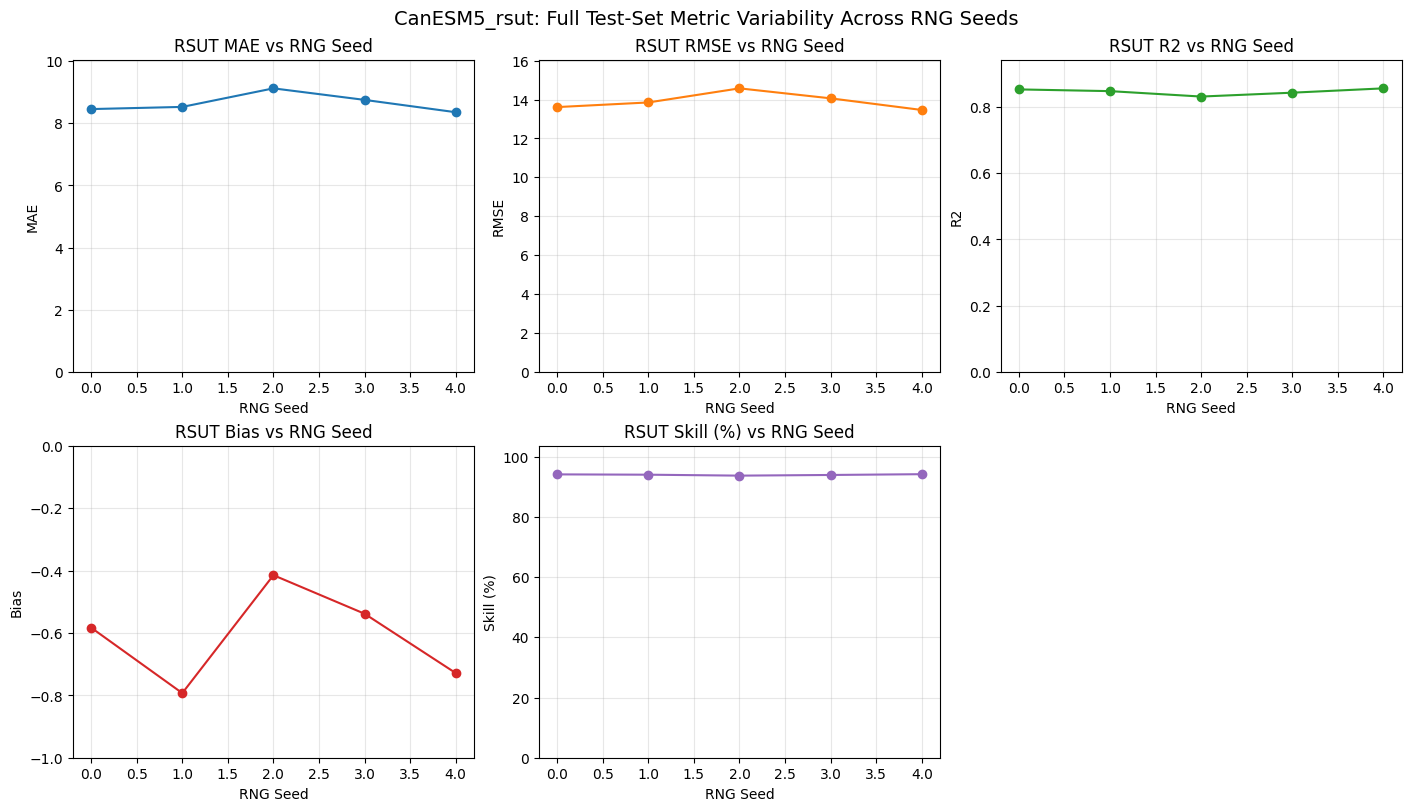

In [12]:
# Evaluate variability across rngseed0-4 for rsut
seed_list = [0, 1, 2, 3, 4]
rsut_seed_metrics = []

for seed in seed_list:
    m = evaluate_full_testset("CanESM5_rsut", rng_seed=seed)
    rsut_seed_metrics.append(m)

print("CanESM5_rsut full test-set metrics by random seed:")
print("Seed   MAE      RMSE      R2       Bias     Skill(%)")
for m in rsut_seed_metrics:
    print(f"{m['rng_seed']:<5}  {m['MAE']:.4f}   {m['RMSE']:.4f}   {m['R2']:.4f}   {m['Bias']:.4f}   {m['SkillPercent']:.2f}")

# Build arrays for plotting and variability summaries
mae_vals = np.array([m["MAE"] for m in rsut_seed_metrics])
rmse_vals = np.array([m["RMSE"] for m in rsut_seed_metrics])
r2_vals = np.array([m["R2"] for m in rsut_seed_metrics])
bias_vals = np.array([m["Bias"] for m in rsut_seed_metrics])
skill_vals = np.array([m["SkillPercent"] for m in rsut_seed_metrics])

print("\nVariability summary across seeds (rsut):")
print(f"MAE   mean={mae_vals.mean():.4f}, std={mae_vals.std(ddof=0):.4f}, min={mae_vals.min():.4f}, max={mae_vals.max():.4f}")
print(f"RMSE  mean={rmse_vals.mean():.4f}, std={rmse_vals.std(ddof=0):.4f}, min={rmse_vals.min():.4f}, max={rmse_vals.max():.4f}")
print(f"R2    mean={r2_vals.mean():.4f}, std={r2_vals.std(ddof=0):.4f}, min={r2_vals.min():.4f}, max={r2_vals.max():.4f}")
print(f"Bias  mean={bias_vals.mean():.4f}, std={bias_vals.std(ddof=0):.4f}, min={bias_vals.min():.4f}, max={bias_vals.max():.4f}")
print(f"Skill mean={skill_vals.mean():.2f}, std={skill_vals.std(ddof=0):.2f}, min={skill_vals.min():.2f}, max={skill_vals.max():.2f}")

# Visual comparison across rng seeds
fig, axs = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
axs = axs.ravel()

plot_series = [
    (mae_vals, "MAE", "tab:blue"),
    (rmse_vals, "RMSE", "tab:orange"),
    (r2_vals, "R2", "tab:green"),
    (bias_vals, "Bias", "tab:red"),
    (skill_vals, "Skill (%)", "tab:purple"),
]

for i, (vals, label, color) in enumerate(plot_series):
    ax = axs[i]
    ax.plot(seed_list, vals, marker="o", color=color)
    ax.set_title(f"RSUT {label} vs RNG Seed")
    if vals.max() > 0:
        ax.set_ylim(0, vals.max() * 1.1)
    else:
        ax.set_ylim(-1, 0)
    ax.set_xlabel("RNG Seed")
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)

# Hide unused panel
axs[5].axis("off")

fig.suptitle("CanESM5_rsut: Full Test-Set Metric Variability Across RNG Seeds", fontsize=14)

out_metrics_plot = FIGURES_DIRECTORY / "CanESM5_rsut_rngseed_variability_metrics.png"
fig.savefig(out_metrics_plot, dpi=250, bbox_inches="tight")
print(f"\nSaved seed-variability plot: {out_metrics_plot}")

plt.show()

Generated predictions from model: CanESM5_rlut_rngseed0_model.keras
Generated predictions from model: CanESM5_rlut_rngseed1_model.keras
Generated predictions from model: CanESM5_rlut_rngseed2_model.keras
Generated predictions from model: CanESM5_rlut_rngseed3_model.keras
Generated predictions from model: CanESM5_rlut_rngseed4_model.keras
CanESM5_rlut full test-set metrics by random seed:
Seed   MAE      RMSE      R2       Bias     Skill(%)
0      5.3019   7.5866   0.8053   0.7359   94.41
1      5.6584   8.2856   0.7678   0.9236   93.89
2      6.5047   9.4928   0.6952   0.7353   93.01
3      5.3018   7.5837   0.8055   0.7245   94.41
4      5.2471   7.5112   0.8092   0.8377   94.47

Variability summary across seeds (rlut):
MAE   mean=5.6028, std=0.4742, min=5.2471, max=6.5047
RMSE  mean=8.0920, std=0.7551, min=7.5112, max=9.4928
R2    mean=0.7766, std=0.0434, min=0.6952, max=0.8092
Bias  mean=0.7914, std=0.0779, min=0.7245, max=0.9236
Skill mean=94.04, std=0.56, min=93.01, max=94.47

Sav

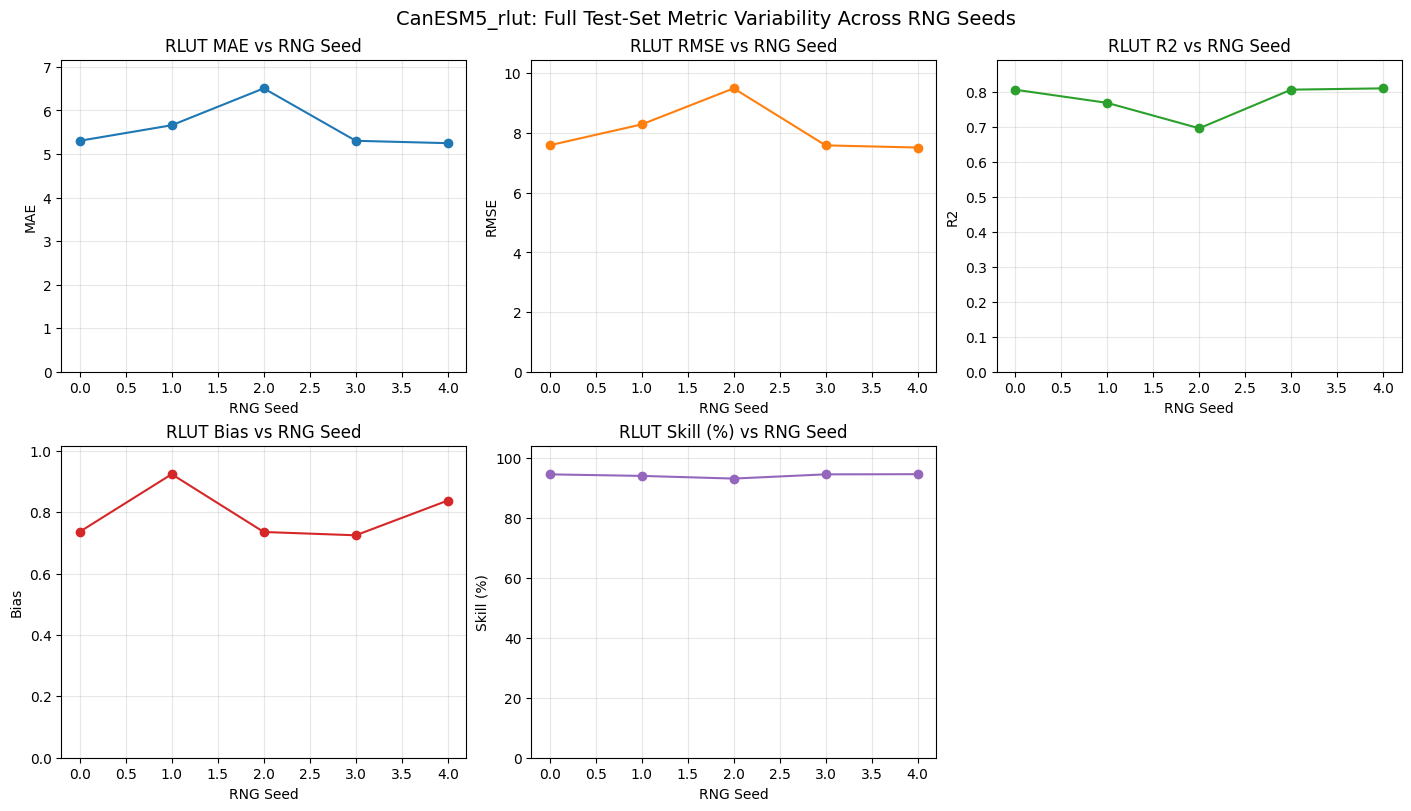

In [11]:
# Evaluate variability across rngseed0-4 for rlut
seed_list = [0, 1, 2, 3, 4]
rlut_seed_metrics = []

for seed in seed_list:
    m = evaluate_full_testset("CanESM5_rlut", rng_seed=seed)
    rlut_seed_metrics.append(m)

print("CanESM5_rlut full test-set metrics by random seed:")
print("Seed   MAE      RMSE      R2       Bias     Skill(%)")
for m in rlut_seed_metrics:
    print(f"{m['rng_seed']:<5}  {m['MAE']:.4f}   {m['RMSE']:.4f}   {m['R2']:.4f}   {m['Bias']:.4f}   {m['SkillPercent']:.2f}")

# Build arrays for plotting and variability summaries
mae_vals = np.array([m["MAE"] for m in rlut_seed_metrics])
rmse_vals = np.array([m["RMSE"] for m in rlut_seed_metrics])
r2_vals = np.array([m["R2"] for m in rlut_seed_metrics])
bias_vals = np.array([m["Bias"] for m in rlut_seed_metrics])
skill_vals = np.array([m["SkillPercent"] for m in rlut_seed_metrics])

print("\nVariability summary across seeds (rlut):")
print(f"MAE   mean={mae_vals.mean():.4f}, std={mae_vals.std(ddof=0):.4f}, min={mae_vals.min():.4f}, max={mae_vals.max():.4f}")
print(f"RMSE  mean={rmse_vals.mean():.4f}, std={rmse_vals.std(ddof=0):.4f}, min={rmse_vals.min():.4f}, max={rmse_vals.max():.4f}")
print(f"R2    mean={r2_vals.mean():.4f}, std={r2_vals.std(ddof=0):.4f}, min={r2_vals.min():.4f}, max={r2_vals.max():.4f}")
print(f"Bias  mean={bias_vals.mean():.4f}, std={bias_vals.std(ddof=0):.4f}, min={bias_vals.min():.4f}, max={bias_vals.max():.4f}")
print(f"Skill mean={skill_vals.mean():.2f}, std={skill_vals.std(ddof=0):.2f}, min={skill_vals.min():.2f}, max={skill_vals.max():.2f}")

# Visual comparison across rng seeds
fig, axs = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
axs = axs.ravel()

plot_series = [
    (mae_vals, "MAE", "tab:blue"),
    (rmse_vals, "RMSE", "tab:orange"),
    (r2_vals, "R2", "tab:green"),
    (bias_vals, "Bias", "tab:red"),
    (skill_vals, "Skill (%)", "tab:purple"),
]

for i, (vals, label, color) in enumerate(plot_series):
    ax = axs[i]
    ax.plot(seed_list, vals, marker="o", color=color)
    ax.set_title(f"RLUT {label} vs RNG Seed")
    if vals.max() > 0:
        ax.set_ylim(0, vals.max() * 1.1)
    else:
        continue
    ax.set_xlabel("RNG Seed")
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)

# Hide unused panel
axs[5].axis("off")

fig.suptitle("CanESM5_rlut: Full Test-Set Metric Variability Across RNG Seeds", fontsize=14)

out_metrics_plot = FIGURES_DIRECTORY / "CanESM5_rlut_rngseed_variability_metrics.png"
fig.savefig(out_metrics_plot, dpi=250, bbox_inches="tight")
print(f"\nSaved seed-variability plot: {out_metrics_plot}")

plt.show()

In [ ]:
# error vs epochs for rlut and rsut
